In [111]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle


from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]

In [113]:
folder = '../../computer_vision/lesson_12/data/subset_homework'

def printClass(folder, classpath):
    
    fnames = os.listdir(os.path.join(folder, classpath))
    images = [cv2.imread(os.path.join(folder, classpath, f), cv2.IMREAD_UNCHANGED) for f in fnames]    
    print(f"size of {classpath} :", np.array(images).shape)
    return images

images0 = printClass(folder, 'class_id_0')
labels0 = [0] * len(images0)

images1 = printClass(folder, 'class_id_1')
labels1 = [1] * len(images1)

size of class_id_0 : (2220, 28, 28)
size of class_id_1 : (2250, 28, 28)


In [114]:
# Put together and shuffle the data
images = images0 + images1
labels = labels0 + labels1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print('Images', images.shape)
print('Labels', labels.shape)

Images (4470, 28, 28)
Labels (4470,)


In [125]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input
print(tf.__version__)

pixels = np.array([image.flatten() for image in images]) / 255.0
print("pixels : ", pixels.shape)
inputs = Input(shape=(pixels.shape[1],))
outputs = Dense(1, activation="linear")(inputs)
# outputs = Dense(1)(outputs)
model = Model(inputs, outputs)

model.summary()

model.compile(optimizer ='adam', loss = 'mean_squared_error')

history = model.fit(pixels, labels, epochs=10, batch_size=32)

2.16.2
pixels :  (4470, 784)


Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_40 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2916
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2115
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1745
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1528
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1379
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1199
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1125
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1068
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0993
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0966


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy =  0.9217002237136466


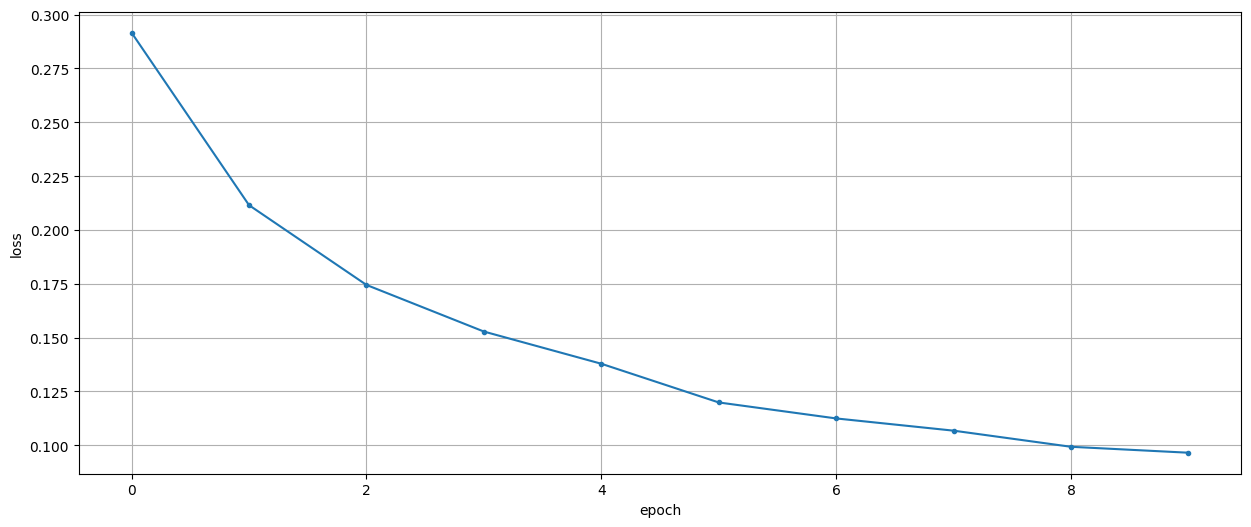

In [126]:
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5
correct = 0

for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct  = correct + 1

# Accuracy =  0.9691275167785235 1 dense layers / 30 epochs
# Accuracy =  0.9648769574944072 - 2 dense layers/ 30 epochs
print('Accuracy = ', correct/len(labels))

# I want able significantly to increase accuracy from 90% to 96%